# Clase práctica del 17/9

In [2]:
import numpy as np
import numpy.typing as npt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.linear_model import Perceptron
import matplotlib.pyplot as plt
from typing import Tuple

In [3]:
class PerceptronSimple:
    """
    Clase que representa a una neurona

    # Atributos:
    - weights: ndarray[float] - Son los pesos de la neurona
    - bias: float - Umbral
    - learning_rate: float - Tasa de aprendizaje
    - epochs: int - Cantidad de épocas

    # Métodos:
    - __init__(self, learning_rate, epochs) - Constructor de la clase
    - reporte(self) - Reporta los pesos y el bias
    - activation(self, z) - Función de activación (Heaviside)
    - fit(self, X, y) - Entrena la neurona con los datos de entrada y salida
    - predict(self, X) - Predice la salida para los datos de entrada
    """
    weights: npt.NDArray[np.float64]
    bias: float
    learning_rate: float
    epochs: int

    def __init__(self, learning_rate: float, epochs: int):
        self.weights = None # type: ignore
        self.bias = None # type: ignore
        self.learning_rate = learning_rate
        self.epochs = epochs
    

    def reporte(self) -> tuple[npt.NDArray[np.float64], float]:
        """
        Reporta los pesos y el bias de la neurona
        """
        return self.weights, self.bias
    
        # Función de activación: Heaviside
    def activation(self, z: npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
        """
        Función de activación: Heaviside

        # Parámetros:
        - z: ndarray[float] - Producto escalar de entradas y pesos + b

        # Retorna:
        - ndarray[float] - Salida de la función de activación
        """
        return np.heaviside(z, 0)
    
    def fit(self, X: npt.NDArray[np.float64], y: npt.NDArray[np.float64]) -> Tuple[npt.NDArray[np.float64], float]:
        """
        Entrena la neurona con los datos de entrada y salida

        # Parámetros:
        - X: ndarray[float] - Datos de entrada
        - y: ndarray[float] - Datos de salida

        # Retorna:
        - tuple[ndarray[float], float] - Los pesos y el bias entrenados
        """
        n_features = X.shape[1]
        
        # Inicialización de parámetros (w y b)
        self.weights = np.zeros((n_features))
        self.bias = 0
        
        # Iterar n épocas
        for _ in range(self.epochs):
            
            # De a un dato a la vez
            for i in range(len(X)):
                # Calcular la salida de la neurona
                z = np.dot(X, self.weights) + self.bias # Producto escalar de entradas y pesos + b
                y_pred = self.activation(z)             # Función de activación no lineal (Heaviside)
                
                #Actualización de pesos y bias
                self.weights = self.weights + self.learning_rate * (y[i] - y_pred[i]) * X[i]
                self.bias = self.bias + self.learning_rate * (y[i] - y_pred[i])
                
        return self.weights, self.bias
    
    def predict(self, X: npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
        """
        Predice la salida para los datos de entrada

        # Parámetros:
        - X: ndarray[float] - Datos de entrada

        # Retorna:
        - ndarray[float] - Salida predicha
        """
        z = np.dot(X, self.weights) + self.bias
        return self.activation(z)

In [6]:
x, iris_target = load_iris(return_X_y=True) 

X = x[:, (0, 1)] # petal length, petal width
y = np.asarray(iris_target == 0, dtype=int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

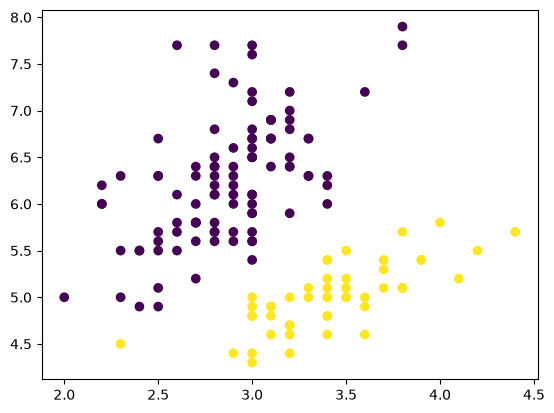

In [7]:
# plot
fig, ax = plt.subplots()
ax.scatter(X[:,1], X[:,0],c=y)
plt.show()

In [62]:
perceptron = PerceptronSimple(0.001, 100)

perceptron.fit(X_train, y_train)

pred = perceptron.predict(X_test)

accuracy_score(pred, y_test)

0.96

In [63]:
perceptron.reporte()

(array([-0.0396,  0.0663]), 0.028000000000000018)

In [64]:
report = classification_report(pred, y_test, digits=2)
print(report)

              precision    recall  f1-score   support

         0.0       0.93      1.00      0.97        43
         1.0       1.00      0.91      0.95        32

    accuracy                           0.96        75
   macro avg       0.97      0.95      0.96        75
weighted avg       0.96      0.96      0.96        75



In [65]:
sk_perceptron = Perceptron()
sk_perceptron.fit(X_train, y_train)
sk_perceptron_pred = sk_perceptron.predict(X_test)

# Accuracy

accuracy_score(sk_perceptron_pred, y_test)


0.88

In [66]:
report = classification_report(sk_perceptron_pred, y_test, digits=2)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.84      0.91        55
           1       0.69      1.00      0.82        20

    accuracy                           0.88        75
   macro avg       0.84      0.92      0.86        75
weighted avg       0.92      0.88      0.89        75

